# Imports

In [2]:
import numpy as np
# import scipy
import scipy.integrate as integ
import scipy.stats as si


from scipy.fftpack import fft
from scipy import interpolate
from scipy.special import ndtr

# from scipy import stats
# from scipy.optimize import basinhopping

from vix_price.balck_scholes.bs_pricers import bs_call
from vix_price.balck_scholes.implied_volatility import implied_volatility, IV_METHODS

import time

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [4]:
import seaborn as sns

In [7]:
list(zip([0, 1, 2, 3],['ab', 'cd']))

[(0, 'ab'), (1, 'cd')]

# Cont Kokhlom model:

The forward variance swap rate, quoted at date t for the period $[T_i,\, T_{i+1}]$ is the strike that sets the value of a forward variance swap running from $T_i$ to $T_{i+1}$ to zero at time t; it is given by

$$
V^{T_1, T_{2}}_t := \frac{\mathbb{E}\Big[[\log S]_{T_{2}} - [\log S]_{T_1}|\mathcal{F}_t\Big]}{T_{2}-T_1}
$$
forward variance swap rates are martingales.

We define the forward variance swap rate over the time interval $[T_i,\, T_{i+1}]$ as
$$
V^i_{t} := V^{T_i, T_{i+1}}_{t}
$$

# Variance Swap Dynamics

Given that the forward variance swap rate is a (positive) martingale under the pricing measure, we model it as
$$V_{t}^{i}=V_{0}^{t} e^{X_{i}}
=V_{0}^{i} \exp \left\{\int_{0}^{t} \mu_{s}^{i} d s+\int_{0}^{t}\omega e^{-k_{1}\left(T_{i}-s\right)} d Z_{s}+\int_{0}^{t} \int_{\mathbb{R}} e^{-k_{2}\left(T_{i}-s\right)} x J(d x ds)\right\}
$$

where $J(d x d t)$ is a Poisson random measure with compensator $v(d x) d t$ and $Z$ a Wiener process independent of $J .$ The martingale condition imposes
$$
\mu_{t}^{i}=-\frac{1}{2} \omega^{2} e^{-2 k_{1}\left(T_{i}-t\right)}-\int_{\mathbb{R}}\left(\exp \left\{e^{-k_{2}\left(T_{i}-t\right)} x\right\}-1\right) v(d x)
$$
For $t>T_{i}$ we let $V_{t}^{i}=V_{T_{i}}^{i} .$ In the case of finite jump intensity (3.1) reduces to
(3.3)
$$
V_{t}^{i}=V_{0}^{i} \exp \left\{\int_{0}^{t} \mu_{s}^{i} d s+\int_{0}^{t} \omega e^{-k_{1}\left(T_{i}-s\right)} d Z_{s}+\sum_{j=0}^{N_{t}} e^{-k_{2}\left(T_{i}-\tau_{j}\right)} Y_{j}\right\}
$$

- # Gaussian Jumps:
    $$
    v(d x)=\lambda \frac{1}{\delta \sqrt{2 \pi}} e^{-\frac{(x-m)^{2}}{2 \delta^{2}}} d x
    $$

- # Kou's two-sided exponential distribution:
    $$
    v(d x)=\lambda\left(p \alpha_{+} e^{-\alpha_{+} x} \mathbf{1}_{x \geq 0}+(1-p) \alpha_{-} e^{-\alpha_{-}|x|} \mathbf{1}_{x<0}\right) d x
    $$

Characteristic functions of variance swaps and VIX futures from  Cont&Kokhlom model.

# A class for model parameters

In [25]:
from dataclasses import dataclass

@dataclass  
class BasicModelParameters:
    model_type: str 

class VIXBlackScholesModelParameters(BasicModelParameters):
    """
    A class for the parameters of the Black-Scholes model in Cont & Kokhlom paper
    """
    model_type: str = 'Black-Scholes'
    sigma: float = 0.3275

class VIXMertonModelParameters(BasicModelParameters):
    """
    A class for the parameters of the Merton model in Cont & Kokhlom paper
    """
    model_typeL: str = 'Merton'
    rho: float = -0.45
    omega: float = 2.04
    lmbd: float  = 3.52
    k1: float  = 21.9
    k2: float  = 2.07
    m: float  = 0.54
    delta: float  = 0.25
    
class VIXKouModelParameters(BasicModelParameters):
    """
    A class for the parameters of the Kou model in Cont & Kokhlom paper
    """
    model_type: str = 'Kou'
    rho: float = -0.45
    omega: float = 1.98
    lmbd: float  = 13.6
    k1: float  = 22.3
    k2: float  = 2.20
    p: float  = 0.86
    alpha_plus: float  = 4.25
    alpha_minus: float  = 19.9
    

class vix_model_parameters():
    """
    A class for the parameters of the model in Cont & Kokhlom paper
    """
    def __init__(self, model_type = 'Merton'):
        self.model_type = model_type
        
        
        #initialize the parameters with the values from Cont & Kokhlom paper
        if model_type == 'Merton':
            self.rho = -0.45
            self.omega = 2.04
            self.lmbd = 3.52
            self.k1 = 21.9
            self.k2 = 2.07
            self.m = 0.54
            self.delta = 0.25
        
        if model_type == 'Kou':
            self.rho = -0.45
            self.omega = 1.98
            self.lmbd = 13.6
            self.k1 = 22.3
            self.k2 = 2.20
            self.p = 0.86
            self.alpha_plus = 4.25
            self.alpha_minus = 19.9
        
        #  we also include the Black-Scholes model
        if model_type == 'Black-Scholes':
            self.sigma = 0.3275
            


# Characteristic functions

In [26]:
def char_func(u, T, model_parameters, asset_type = 'VIX'):
    """
    Computes the value of the caracteristic functions for various models for VIX futures and
    variance swaps. By default, it returns the char. func. for the distirbution of VIX futures
    price in Merton's model introduced in Cont&Kokhlom paper.
    """
    
    #define the ceoefficents corresponding to 'VIX' and 'var. swap' respectivly
    if asset_type == 'VIX':
        cf_1 = 0.5
        cf_2 = 1/8

    elif asset_type == 'var. swap':
        cf_1 = 1.
        cf_2 = 0.5
        
    model_type = model_parameters.model_type
    
    if model_type=='Black-Scholes':#characteristic function of Black-Scholes
        try:  #  try to import the volatility sigma from params
            sigma = model_parameters.sigma
        except:
            print(f"The sigma (volatlity) parameter of the {model_type} model is missing.")
        return np.exp(-sigma**2*T*(u**2+1j*u)/2)
    
    #if not Black Scholes
    
    #import parameters omega, lmbd, m from params
    try:
        omega, lmbd  = model_parameters.omega, model_parameters.lmbd
        
    except:
        print(f"One or more of omega, lmbd, m parameters of the {model_type} are not specified.")
        
    #import parameters k1, k2 and delta from params   
    try:
        k1, k2 = model_parameters.k1, model_parameters.k2
    except:
        print(f"One or more of k1, k2, delta parameters of the {model_type} are not specified.")
    
    # get the 1s and 2nd terms in teh formulas of the characterisitc functions(see A.2/A.4 in Cont&Kokhlom)
    first_term = -cf_2*omega*omega*1j*u*(1-np.exp(-2*k1*T))/(2*k1)
    second_term = -cf_2*omega*omega*u*u*(1-np.exp(-2*k1*T))/(2*k1)
    
    integral1, integral2 = 0, 0
    
    #first define the integrands in the 3rd and 4th terms in the formulas for
    if model_type =='Merton': # formula A.2 from Cont & Kokhlom paper
        
        try:#try to import the delta parameter from params
            delta, m = model_parameters.delta, model_parameters.m
        except:
            print(f"The parameter delta of the {model_type} is not specified.")  
            
        #First integrand
        integrand1=lambda s: np.exp(cf_1*np.exp(-k2*(T-s))*m\
                                                + cf_2*np.exp(-2*k2*(T-s))*delta*delta)-1
        #Second integrand
        integrand2=lambda s: np.exp(cf_1*1j*u*np.exp(-k2*(T-s))*m\
                                                   - cf_2*u*u*np.exp(-2*k2*(T-s))*delta*delta)-1

        integral1 = integ.quad_vec(integrand1,0,T)
        integral2 = integ.quad_vec(integrand2,0,T)
        
    elif model_type =='Kou':  # formula A.4 from Cont&Kokhlom paper
        
        try:#try to import parameters p, a_plus, a_minus from params
            p, a_plus, a_minus = model_parameters.p, model_parameters.alpha_plus, model_parameters.alpha_minus
        except:
            print(f"One or more of p, a_plus, a_minus parameters of the {model_type} are not specified.")
            
         #First integrand
        integrand1 = lambda s: p*a_plus/(a_plus - cf_1*np.exp(-k2*(T-s)))\
        +(1-p)*a_minus/(a_minus + cf_1*np.exp(-k2*(T-s)))-1
        
        #Second integrand
        integrand2 = lambda s: p*a_plus/(a_plus - cf_1*1j*u*np.exp(-k2*(T-s)))\
        +(1-p)*a_minus/(a_minus + cf_1*1j*u*np.exp(-k2*(T-s)))-1

        integral1 = integ.quad_vec(integrand1,0,T)
        integral2 = integ.quad_vec(integrand2,0,T)
    
    else:  #  other model
            raise ValueError("Unknown model") 
            
    return np.exp(first_term + second_term - 1j*u*lmbd*integral1[0] + lmbd*integral2[0])

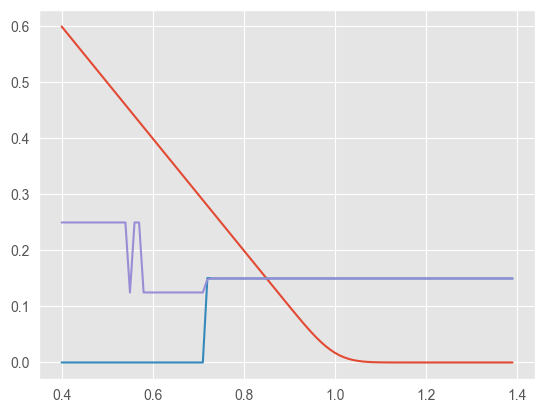

In [9]:
#Testing the functions for implied volatility

kks = np.arange(0.4, 1.4, 0.01)
vol = 0.15
plt.plot(kks, bs_call(1, kks, 1/12, 0., vol))

# plt.plot(kks, bs_vega(1, kks, 1/12, 0., vol));
r = 0.
T = 1./12
imps = [implied_volatility(bs_call(1, K, T, r, vol), 1, K, r, T, method= 'brentq') for K in kks]
imps2 = [implied_volatility(bs_call(1, K, T, r, vol), 1, K, r, T, method='iterative') for K in kks]
sns.lineplot(x=kks, y=imps);
sns.lineplot(x=kks, y=imps2);


In [10]:
#Testing

#Merton models parameters
# params1 =  vix_model_parameters('Merton')
params1 = VIXMertonModelParameters()
#Kou models parameters
# params2 =  vix_model_parameters('Kou')
params2 = VIXKouModelParameters()

#B-S models parameters
params3 =  vix_model_parameters('Black-Scholes')
params3.sigma = 0.252

char_func(0.5, 1/12, params1, asset_type = 'VIX'),\
char_func(0.5, 1/12, params2, asset_type = 'VIX'),\
char_func(0.5, 1/12, params3, asset_type = 'VIX')

NameError: name 'vix_model_parameters' is not defined

The drif coefficient is
$$
 \mu^i(t) := -\frac{1}{2}\omega^2 e^{-2k_1(T_i-t)} - \int_{\mathbb{R}}(exp(-k_2(T_i-t) x) - 1)\nu(dx)
$$
the next function calculate the drift term in the variance swap dynamics, given byt the integral
$$
\text{Merton:} \int_0^{T_i} \mu^i(t)dt = -\frac{1}{2 }\omega^2 \frac{1- e^{-2k_1 T_i}}{2 k_1}- \lambda \int_0^{T_i} \left(e^{m e^{-k_2 (T_i-s)}+ \frac{1}{2} e^{-2 k_2 (T_i-s)} \delta^2}-1 \right)ds
$$

$$
\text{Kou:} \int_0^{T_i} \mu^i(t)dt = -\frac{1}{2 }\omega^2 \frac{1- e^{-2k_1 T_i}}{2 k_1}-
\lambda \int_0^{T_i} \left(p \frac{\alpha_{+}}{\alpha_{+} - e^{-k_2 (T_i-s)}}+(1-p)\frac{\alpha_{-}}{\alpha_{-} + e^{-k_2(T_i-s)}}-1\right)ds
$$

In [28]:

 def vix_drift_coeff(T, model_parameters):#computes the drift part in (3.1) of Cont&Kokhlom
    """
    Computes the drift term of the variance swap rate given by th Cont&Kokhlom model
    """
    
    model_type = model_parameters.model_type
    
    try:#try to import parameters omega, lmbd, m from params
        omega, lmbd  = model_parameters.omega, model_parameters.lmbd
    except:
        print(f"One or more of parameters omega, lmbd are not specified.")
        
    try:#try to import parameters k1, k2 and delta from params
        k1, k2 = model_parameters.k1, model_parameters.k2
        
    except:
        print(f"One or more of k1, k2 parameters of the {model_type} are not specified.")
    
    if model_type =='Merton':
        try:#try to import the delta parameter from params
            m, delta = model_parameters.m, model_parameters.delta
        except:
            print(f"One of parameters m, delta of the {model_type} model is not specified.")
            
        integrand = lambda s: np.exp(np.exp(-k2*(T-s))*m\
                                                + 0.5*np.exp(-2*k2*(T-s))*delta**2)-1
        
    elif model_type == 'Kou':
        try:#try to import parameters p, a_plus, a_minus from params
            p, a_plus, a_minus = model_parameters.p, model_parameters.alpha_plus, model_parameters.alpha_minus
        except:
            print(f"One or more of p, a_plus, a_minus parameters of the {model_type} model are not specified.")
        
        integrand = lambda s: p*a_plus/(a_plus - np.exp(-k2*(T-s)))\
        +(1-p)*a_minus/(a_minus + np.exp(-k2*(T-s)))-1
        
    else:#other model
            raise ValueError("Unkown model")
    
    return -0.5*(omega**2)*(1-np.exp(-2*k1*T))/(2*k1) - lmbd*integ.quad_vec(integrand,0,T)[0]

In [29]:
#Testing
vix_drift_coeff(1., params1), vix_drift_coeff(1., params2)

(-1.026645982825763, -1.292068804924341)

In [30]:
def fourier_call_pricer(chr_func, T, r, s_0=0, method='Cont&Tankov'):
    """
    Returns the prices of call options for a list of log moneyness valuues centered around exp(s_0),
    for an asset with given characteristic function, using a Fourier transform methods.
    
    chr_func - characteristic function of the asset
    T - positive float, the expiry (in years)
    r - positive float, the interest rate
    s_0 - a float, the log of the moneyness 
    method - the method used for fuourier tansport, either Cont&Kokhlom or Kar&Madan
    """
    
    #initialising hyperparameters for the Fourier Transform (FT) method
    N = 1024
    Delta = 0.17
    sgm = 0.3575
    bs_model_params = vix_model_parameters('Black-Scholes')
    bs_model_params.sigma = sgm
    
    d = 2*np.pi/(Delta*N)
    A = Delta*(N-1)

    d = 2*np.pi/(Delta*N)
    A = Delta*(N-1)

    #integration grid x_k = -A/2 + k*Delta, k=0, ..., N-1
    xs = np.array([-0.5*A + k*Delta for k in range(N)])

    #Quadrature weights:
    w = np.ones(N)
    w[0] = w[-1] = 0.5
    
    #Simpson's rule quadrature weights
#     w = np.array([3-(-1)**j for j in range(N)])
#     w[0] -= 1
#     w[-1] -=1
#     w = w/3   

    #log moneyness grid u_n = -N*d/2+s_0 + n*d, n = 0, ..., N-1
    us = np.array([-N*d/2+s_0 + n*d for n in range(N)])
    
    if method == 'Cont&Tankov':
        #compute the FT of modified option price
        zeta_T = np.exp(-r*T)*chr_func(xs-1j)
        zeta_T -= np.exp(1j*r*T*xs)*char_func(xs-1j, T, bs_model_params)
        zeta_T /=(1j*xs - xs*xs)

        #compute the inverse fourier transfroorm using FFT
        zs = fft(zeta_T*w*np.exp(-1j*(s_0-N*d/2)*(xs+0.5*A)))
        zs = Delta*np.exp(1j*A*us/2)*zs/(2*np.pi)
        
        #recover the option prices
        ops = zs.real + bs_call(1, np.exp(us), T, r, sgm)
        
    elif method == 'Kar&Madan':
        #an exponent s.t. ES^{alf+1}<+inf
        alf = 0.75
        
        xs = np.array([Delta*k for k in range(N)])
        
        #Fourier Transform of the modified option price
        zeta_T = np.exp(-r*T)*chr_func(xs-(alf+1)*1j)
        zeta_T /= (alf**2+alf-xs*xs+1j*(2*alf+1)*xs)
        
        #Simpson's rule quadrature weights
        w = np.array([3-(-1)**j for j in range(N)])
        w[0] -= 1
        w = w/3
        
        #compute the inverse fourier transfroorm using FFT
        zs = fft(zeta_T*np.exp((N*d/2-s_0)*1j*xs)*w)*Delta
        
        #recover the option prices
        ops = np.exp(-alf*us)*zs.real/(np.pi)
        
    else:#other method
        raise ValueError("Unkown method")
    #return 
    return us, ops
    

# Function to return the VIX option price

In [31]:
def price_vixoptions(V0, K, T, r, model_params,  pricing_method='Cont&Tankov', option_type = 'call'):
    """
    Retruns the price of an option on vix future using Fourier transform method
    """
    moneyness = K/V0

    if option_type == 'call':

        chr_func = lambda x: char_func(x, T,  model_params, asset_type = 'VIX')
        us, ops = fourier_call_pricer(chr_func, r, T, method = pricing_method)

        #interpolate to get prices for moneyness values between the points of np.exp(us)
        f = interpolate.interp1d(np.exp(us), ops)

        return V0*f(moneyness)

    if option_type == 'put':
        return np.exp(-r*T)*K + price_vixoptions(V0, K, T, r, model_params, pricing_method)

In [32]:
# #Testing

# ks = np.arange(0.79, 2., 0.01)#list of different moneyness'

# r = 0.
# T = 1/12

# #Cont&Tankov method gives divison by 0 error for r = 0.
# # ops1 = price_vixoptions(1, ks, T, r, params1, pricing_method ='Cont&Tankov', option_type =  'call')

# ops2 = price_vixoptions(1, ks, T, r, params1, pricing_method ='Kar&Madan', option_type =  'call')

# imp_vols = [implied_volatility(ops2[i], 1, ks[i], T, r) for i in range(len(ks))]

# plt.plot(ks, imp_vols);
# plt.title(f"Expiry {int(12*T)}M, r={r}");

# plt.xticks(np.arange(0.8, 2., 0.2));
# plt.yticks(np.arange(0.4, 1.21, 0.2));
# # plt.plot(ks, bs_call(1, ks, 1/12, 0.05, 0.1));

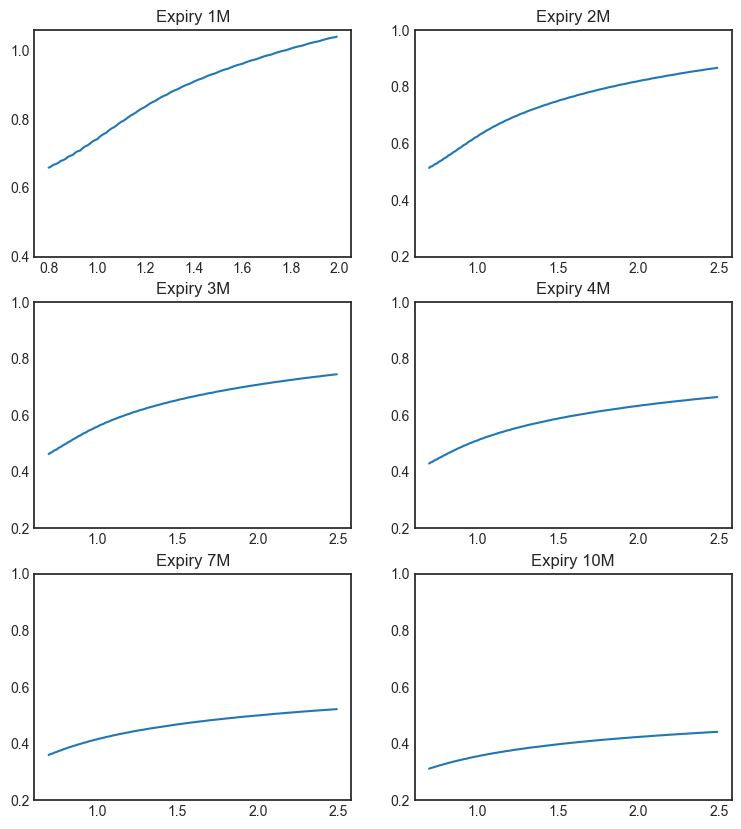

In [33]:
#Testing
#reproducing the results in the paper by Cont&Kokhlom
fig, axs = plt.subplots(3, 2, figsize=(9, 10))

tenor_dates = np.array([0, 1, 2, 3, 4, 7, 10])/12
r = 0.

ks = np.arange(0.8, 2., 0.01)
# plt.xticks(np.arange(0.2, 1.1, 0.2));

for j in range(6):
    
    if j!=0:
        ks = np.arange(0.7, 2.5, 0.01)
    option_prices = price_vixoptions(1, ks, tenor_dates[j+1], r,\
                                     params1, pricing_method ='Kar&Madan')
    
    imp_vols = [implied_volatility(option_prices[i], 1, ks[i], tenor_dates[j+1], r) for i in range(len(ks))]
    
    ax = axs[j//2, j%2]
    ax.plot(ks, imp_vols)
    ax.set_title(f"Expiry {int(12*tenor_dates[j+1])}M");
    if j!=0:
        ax.set_yticks(np.arange(0.2, 1.1, 0.2))
        ax.set_xticks(np.array([1.0, 1.5, 2., 2.5]))
    else:
        ax.set_yticks(np.arange(0.4, 1.2, 0.2))
        ax.set_xticks(np.arange(0.8, 2.1, 0.2))
    
plt.show()

# Function to simulate correlated Brwonian diffsuions increments

In [34]:
def simul_full_diffusions(num_paths, ticks, rho):
    """
    Simulate increments of correlated Brwonian diffsuions
    input:
        num_paths:  number of paths
        ticks: numpy array of floats t_0<...<t_{n-1}, the time steps
        rho: the correlation coefficient
    Output:
    dZ, dW:
    where dZ, dW are two numpy matrices of dimenstion (num_paths, len(ticks)-1) 
    repesneting the correlted Brownian increments, 
    on the intervals t_i - t_{i-1}, i = 1,..., n-1
    """

    dZ = np.random.randn(num_paths,len(ticks)-1)*np.sqrt(np.diff(ticks))
    dW = np.random.randn(num_paths,len(ticks)-1)*np.sqrt(np.diff(ticks))
    dW = rho*dZ+np.sqrt(1-rho**2)*dW

    return dZ, dW

# Function to jump terms for a single period in Merton or Kou model

In [35]:
def simul_total_jumps(T1, T2, num_paths, model_params):
    """
    Simulate jump terms according to the model parameters between the time T1 and T2 
    Input:
        T1 - non-negative float
        T2 - positive float, the terminal time
        num_paths -  number of simulations
        
        model_params - an object of class vix_model_parameters
        
    Outup:
        two 1D numpy arrays corresponding to the
        \sum Y_j  and \sum e^{k2 tau_j} Y_j for each simulations/path
    """
    list_of_jumps = []
    
    model_type = model_params.model_type
    
    #extract the jump intensity
    lmbd = model_params.lmbd
    k2 = model_params.k2
    #number of jumps for each realizations
    numbers_of_jumps = np.random.poisson(lmbd*(T2-T1), size=num_paths)
    #maximal number of jumps out of all realizations
    max_num = np.max(numbers_of_jumps)
    #matrix of 0s & 1s encoding the jump numbers
    a = np.zeros((num_paths, max_num))
    for i in range(num_paths):
        a[i,:numbers_of_jumps[i]] = 1
    
    #simulate the jump times
    jump_times = np.random.uniform(low=T1,high=T2, size=(num_paths, max_num))
    
    if model_type == 'Merton':
        delta, m = model_params.delta, model_params.m
                              
        #initialize jump times and sizes in 2D array
        #simulate the jump times
        jump_sizes = np.random.randn(num_paths, max_num)*delta+m

    elif model_type == 'Kou':
        alpha_plus, alpha_minus, p = model_params.alpha_plus,\
        model_params.alpha_minus, model_params.p
        
        #1 if positive 0 if negtive jump
        jump_type = np.random.choice(2, size=(num_paths, max_num),  p=[1-p, p])
        scales = jump_type*1/alpha_plus - (1-jump_type)*1/alpha_minus

        #get the jump sizes
        jump_sizes =  scales*np.random.exponential(size = (num_paths, max_num))

    total_jumps = np.sum(a*jump_sizes, axis=1)
    vix_jump_terms = np.sum(a*jump_sizes*np.exp(k2*jump_times), axis=1)
    
    return total_jumps, vix_jump_terms

# A function to simulates total jumps for each tenor period at once

both for the index and the variance swaps/VIX

In [36]:
def simul_tenor_jumps(model_params, num_paths = 10**5, tenor_dates = np.arange(0, 1/2, 1/12)):
    """
    Simulates the sum of jumps for each tenor period for the index 
    and 
    the total jump term the varaince for swaps up to each tenor date.

    Arguments:
        tenor_dates - sorted numpy list of tenor dates
        
        model_params - an object of class vix_model_parameters 
                       containing the parameters of the jumps process and the type

    Returns:
        - \sum_{T_{i-1}=<tau_j<T_i} Y_j

        and 

        _ \sum_{tau_j<T_i} exp(-k2*(T_i -tau_j)) Y_j
    """
    
    #we need the k2 parameter
    k2 = model_params.k2
    
    
    #2D arrays of jumps in each tenor peirod for each simulation
    total_jumps = np.zeros((num_paths, len(tenor_dates)-1))
    vix_jumps = np.zeros((num_paths, len(tenor_dates)-1))
    
    for i in range(len(tenor_dates)-1):
        T1 = tenor_dates[i]
        T2 = tenor_dates[i+1]
        total_jumps[:, i], vix_jumps[:, i] = simul_total_jumps(T1, T2, num_paths, model_params)

    return total_jumps, np.exp(-k2*tenor_dates[1:])*np.cumsum(vix_jumps, axis=1)

In [37]:
#Testing
#Simulating and storing the diffusions and jumps for 2*10^6 paths

#take the tenor dates as in the paper
tenor_dates = np.array([0, 1, 2, 3, 4, 7, 10])/12

N = 2*10**6
start = time.time()
SJ, VJ = simul_tenor_jumps(params1, N, tenor_dates)

SJ2, VJ2 = simul_tenor_jumps(params2, N, tenor_dates)
print('Time elapsed:', time.time()-start)

Time elapsed: 108.64348006248474


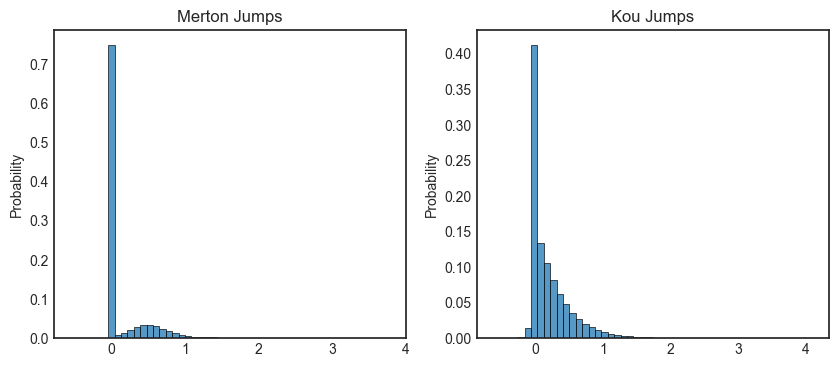

In [38]:
#Test

#ploting the jump sizes for both models

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
ax1.set_title("Merton Jumps")
ax2.set_title("Kou Jumps")
sns.histplot(VJ[:,0],  ax=ax1, bins=50, stat="probability")
sns.histplot(VJ2[:,0], ax=ax2, bins=50, stat="probability")
plt.show()

# A function to simulates total diffusion terms for each tenor date

In [39]:
def simul_tenor_difussions(num_paths, tenor_dates, k1):#
    """
    Simulate the diffusion parts of VIX and the index on tenor dates
    Input:
        num_paths - the size/number of simulations
        tenro_dates - numpy sorted list of tenro dates
        k1 -  float, voaltility scaling parameter
    Outup:
        ZV, Z - two numpy 2D arrays/matrices of dimenstion (num_paths, len(tenor_dates) - 1)

    Z  - each row correspond to a given realisation
         each column represents the value of the diffusion controlling the VIX
         at the correpsonding theor date; Z(T_i) for i = 1, ..., m

    ZV - numpy 2D array, each row to a given realisation, each column represents the
         diffuson term in the volatility swap dynamics given by (3.1) of Cont&Kokhlom paper; 
         ZV_i = \int_{0}^{T_i}exp(k1*(T_i-s))dZ_s.

    """
    #compute the variaces of increments \int_{T_{i-1}}^T_i exp(k1*s) dZ_s, i = 1, ..., m
    variations = np.diff(np.exp(2*k1*tenor_dates))/(2*k1)

    #compute the correlation of Z(T_i) - Z(T_{i-1}) and  \int_{T_{i-1}}^T_i exp(k*s) dZ_s
    correlations = np.diff(np.exp(k1*tenor_dates))/k1


    #simulate independent normal variables for \int_{T_{i-1}}^T_i exp(k*s) dZ_s
    dIZ = np.random.randn(num_paths, len(tenor_dates)-1)*np.sqrt(variations)

    #simulate W(T_i) - W(T_{i-1})
    dZ = np.random.randn(num_paths, len(tenor_dates)-1)
    
    dZ = (correlations/variations)*dIZ +\
    np.sqrt(np.diff(tenor_dates) - correlations*correlations/variations)*dZ

    ZV = np.exp(-k1*tenor_dates[1:])*np.cumsum(dIZ, axis = 1)


    return ZV, dZ

In [40]:
#Testing

#simulate diffusions for the Merton model
ZV, dZ = simul_tenor_difussions(N, tenor_dates, k1=params1.k1)

#simulate diffusions for the Kou model
ZV2, dZ2 = simul_tenor_difussions(N, tenor_dates, k1=params2.k1)


# A function to compute V^i_{T_i}  from stored data

In [41]:
def get_vix_prices(Vi_0, diff_V, jump_V, tenor_dates, model_params):#get V^i_{T_i}
    """
    Given the simulations of diffuison terms and jump terms of the variance swaps
    and the inital values V^0_{T_0}, V^1_{0}, ..., V^{m-1}_{0}
    returns the values at the corresp. tenor dates V^1_T_1, ..., V^{m-1}_T_{m-1}

    Vi_0 - numpy 1D array of shape (m-1,), where m = len(self.tenor_dates)-1,
           inital values of V^i_0 i= 1, ..., m-1

    diff_V - numpy 2D array of shape (N, m-1) of the realised diffusion terms 
             up to each tenro date T_1, ..., T_{m-1}.
             Where N is the number of realised paths.

    jump_V - numpy 2D array of shape (N, m-1) of the realised jump terms 
             up to each tenor date T_1, ..., T_{m-1}.
    
    tenor_dates - sorted numpy list of tenor dates
        
    
    model_params - an object of class vix_model_parameters;
                   the parameters and the type
    
    """
    #check if the inputs sizes match
#     if np.shape(diff_V)!= np.shape(jump_V) or len(Vi_0) != len(diff_V):
#         raise Error("The dimensons of diffusions and jumps_list do not match.")

    #get the constant drift terms \int_0^T_i mu_i(t)dt
    m = len(tenor_dates)-1
    tenor_drifts = np.zeros(m-1)
    
    for i in range(m-1):
        tenor_drifts[i] = vix_drift_coeff(tenor_dates[i+1], model_params)
    
    VT_i = Vi_0[0]*np.ones((len(diff_V), len(Vi_0)))
    
    VT_i[:,1:] = Vi_0[1:]*np.exp(tenor_drifts + model_params.omega*diff_V + jump_V)
                   
    return VT_i

In [42]:
#Testing

#initial prices V^0_{T_0}, V^1_{0}, ..., V^{m-1}_{0}
Vi_0 = np.array([0.041, 0.052, 0.056, 0.059, 0.062, 0.061])

#prices at V^1_{T_1}, V^2_{T_2}, ..., V^{m-1}_{T_{m-1}}
VT_i1 = get_vix_prices(Vi_0, ZV[:,:-1], VJ[:,:-1], tenor_dates, params1)

VT_i2 = get_vix_prices(Vi_0, ZV2[:,:-1], VJ2[:,:-1], tenor_dates, params2)

#checking the martingale property; the following values should be close to 1.
np.mean(VT_i1/Vi_0, axis =0), np.mean(VT_i2/Vi_0, axis =0)

(array([1.        , 0.9997904 , 1.00019323, 0.99997106, 0.99991899,
        1.00065764]),
 array([1.        , 0.9996539 , 0.99908272, 0.9995313 , 0.99886005,
        0.99930319]))

# A function to compute sigma^i  from stored data

In [43]:
def get_sigmas(Vi0, VTi, constraint_cf,  b_i):#sigam_i paths for scenario
    """
    Compute the thenor volatilites sigam_i, from the inital variance swap prices
    and given ralisations/simulations of the variance swap prices at tenor dates.

    Inputs:
    -------

        Vi0 - numpy 1D array of length k <= len(self.tenor_dates)-1, of inital k values
               of V^i_0 i = 0, 1, ..., k-1. (note that this requires also V^0_0=V^0_{T_0})

        VTi - nump 2D array of shape (N, k) realisations/simulations of the variance swap
              prices at tenor dates; V^0_{T_0}, V^1_{T_1}, ..., V^{k-1}_{T_{k-1}}

        b_i  - numpy 1D array of length m; the model coeeficients for the index jumps in the 
              definitions u_i(V^i_T_i, x) from the Cont&Kokhlom formula (3.19)
              b_i[i] correpsonds to the period [T_i, T_{i+1}], i = 0, 1, ..., k-1.
        
        lmbd - flaot, the intensity paramerer
        
        constraint_cf - the coefficent in the formula:
                        (σ_i)^2 = V^i_{T_i} - lambda* b_i^2 * (constraint_cf)
    Returns:
    --------       
        sigmas_sq - numpy 2D array of shape (N, k-1), with N rows corresponding to each realisation,
                 the columns (σ_0)^2, ..., (σ_{k-1})^2 are lenght N nump araays representing the squared
                 vloatility coefficents of the index diffusion in each of tenor periods
                 [T_0, T_1], ..., [T_{k-1}, T_k] (for each of N realisations)

    """
    #initalize with zeros
    sigmas_sq= VTi - (constraint_cf) * (VTi/Vi0) * (b_i**2)

    return sigmas_sq


In [44]:
#Testing
lmbd = params1.lmbd

lmbd2 = params2.lmbd


b_i1 = np.array([-0.140, -0.161, -0.162, -0.187, -0.198, -0.199])

b_i2 = np.array([-0.141, -0.159, -0.158, -0.187, -0.195 , -0.192])

constraint_cf2 = 2*lmbd2*(params2.p/(params2.alpha_plus**2)+(1-params2.p)/(params2.alpha_minus**2))

constraint_cf1 = lmbd*(params1.m**2+params1.delta**2)



#sigma_0, sigma_1, ..., sigma_{m-1}
sigmas_sq1 = get_sigmas(Vi_0, VT_i1, constraint_cf1,  b_i1)
sigmas_sq2 = get_sigmas(Vi_0, VT_i2, constraint_cf2,  b_i2)

#compute E(σ_i)^2 for the Merton and Kou models
np.mean(sigmas_sq1, axis = 0), np.mean(sigmas_sq2, axis = 0)

(array([0.01656993, 0.01968711, 0.02329314, 0.01541307, 0.01313382,
        0.0116477 ]),
 array([0.01506176, 0.01900994, 0.02340861, 0.01337056, 0.01237562,
        0.01289548]))

# A function to compute U_T_m  from stored data

In [45]:
def get_UTm(Vi_0, VT_i, diff_Z, jumps_S, sigmas_sq,  b_i, tenor_dates, model_params):
    """
    Given the simulations/realisations of diffuison terms and jump terms of the index,
    the variance swap prices, the sigmai squared and the bi coefficents returns the values
    of  the auxilliary price U_{T_k}.
    
    Inputs:
    -------

        Vi_0 - numpy 1D array of length m = len(self.tenor_dates) - 1, of inital values
               of V^i i = 0, 1, ..., k-1. (note that this requires also V^0_0=V^0_T_0)

        VT_i - nump 2D array of shape (N, k - 1) realisations/simulations of the variance swap
              prices at tenor dates; V^1_{T_1}, ..., V^{k-1}_{T_{k-1}}

        b_i  - numpy 1D array of length m; the model coeeficients for the index jumps in the 
              definitions u_i(V^i_T_i, x) from the Cont&Kokhlom formula (3.19)
              bi[i] correpsonds to the period [T_i, T_{i+1}], i = 0, 1, ..., k-1.

        diff_Z - nump 2D array of shape (N, k - 1) realisations/simulations of the increments
                 of the diffusion controling the index prices; the stored values of 
                 Z(T_{i+1}) - Z(T_i), i = 0, 1, ..., k-1.


        jumps_S - numpy 2D array of shape (N, k-1) of the realised total jump of the index 
                  in each tenor period [T_0, T_1], ..., [T_{k-1}, T_k].


        sigmas_sq - numpy 2D array of shape (N, k), with N rows corresponding to each realisation,
                 the columns (σ_0)^2, ..., (σ_{k-1})^2 are lenght N nump araays representing the squared
                 vloatility coefficents of the index diffusion in each of tenor periods
                 [T_0, T_1], ..., [T_{k-1}, T_k] (for each of N realisations). 
        
        model_params - an object of class vix_model_parameters representing the model
                       parameters and the type
    Return:
    -------
        U_{T_k} - nonegative float value, (see page 259 from Cont&Kokhlom)
    """
    #comute the coefficents in u_i(., x)
#     ui_factors = b_i[0]*np.ones((len(VT_i), len(b_i)))# since V^0_T_0 = V^0_0 the firs coef. is b_0
    #update the the conefficents wit indecies 1, ..., k-1
    ui_factors = np.sqrt(VT_i/Vi_0)*b_i

    model_type = model_params.model_type
    #comute the integral \int ( e^(u_i(., x)) - 1 ) v(dx) in the drift term
    lmbd =  model_params.lmbd
    
    #unpack the model parameters
    if model_type == 'Merton':
        m, delta = model_params.m, model_params.delta
        integral = lmbd*(np.exp((m*ui_factors + 0.5*(delta**2)*(ui_factors**2))) - 1)
        
    elif model_type == 'Kou':
        p, a_plus, a_minus = model_params.p, model_params.alpha_plus, model_params.alpha_minus
        integral = lmbd*(p*a_plus/(a_plus-ui_factors) + (1-p)*a_minus/(a_minus+ui_factors) - 1)

    drift_term = np.sum(-(0.5*(model_params.rho**2)*sigmas_sq + integral)*np.diff(tenor_dates), axis=1)

    diffusion_term = model_params.rho*np.sum(diff_Z * np.sqrt(sigmas_sq), axis=1)

    jump_term = np.sum(jumps_S * ui_factors, axis=1)


    return np.exp(drift_term+diffusion_term+jump_term)

In [46]:
#Testing
k = 6
UTs_merton = get_UTm(Vi_0[:k], VT_i1[:,:k], dZ[:,:k], SJ[:,:k], sigmas_sq1[:,:k],\
                   b_i1[:k], tenor_dates[:k+1], params1)

UTs_kou = get_UTm(Vi_0[:k], VT_i2[:,:k], dZ2[:,:k], SJ2[:,:k], sigmas_sq2[:,:k],\
                   b_i2[:k], tenor_dates[:k+1], params2)

In [47]:
#checking the martingale property of U_{T_m}
np.mean(UTs_merton), np.mean(UTs_kou)

(0.9997206018705401, 1.0001527461578492)

In [48]:
# fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
# ax1.set_title("Merton U_T_m")
# ax2.set_title("Kou U_T_m")
# sns.histplot(UTs_merton,  ax=ax1, bins = 95, shrink = 0.7)
# sns.histplot(UTs_kou,ax=ax2, bins = 95, shrink = 0.7)
# plt.show()

# Store DATA

In [49]:
start = time.time()
#simulate and store jumps and the diffusion terms per each tenor period
num_paths = 2*10**6


#diffusions for Merton model
diff_V, diff_Z = simul_tenor_difussions(num_paths, tenor_dates, k1=params1.k1)

#jumps for Merton model
jumps_S, jumps_V = simul_tenor_jumps(params1, num_paths, tenor_dates)
end = time.time()
print('time elapsed: ', end-start)

time elapsed:  30.19064497947693


In [50]:
#compute the varince swap rate at each tenor date
#for each simulation of diffusions and jumps stored above
VT_i = get_vix_prices(Vi_0, diff_V[:,:-1], jumps_V[:,:-1], tenor_dates, params1)

#the full stored data
stored_data = [diff_V, diff_Z, jumps_S, jumps_V, VT_i]


In [51]:
#Testing

#comuting the realised (\sigam_i)^2
sigmas_sq = get_sigmas(Vi_0, VT_i, constraint_cf1,  b_i1)

In [52]:
#Testing

#compute E(\sigam_i)^2 to compare with the results in the paper
np.round(np.mean(sigmas_sq, axis=0),3)

array([0.017, 0.02 , 0.023, 0.015, 0.013, 0.012])

In [53]:
#checking the martingale property
np.mean(VT_i/Vi_0, axis = 0), np.mean(sigmas_sq, axis=0)

(array([1.        , 0.99996854, 0.99992112, 0.99972243, 1.00044655,
        1.00000399]),
 array([0.01656993, 0.01969062, 0.0232868 , 0.01540924, 0.01314075,
        0.01164009]))

# A pricer function for Index options

In [54]:
def price_index_options(S0, Vi_0, strikes, r,  tenor_dates, stored_data, b_i, model_params,  option_type = 'call'):
    """
    Retruns the prices of an Index option with expiry at the model's tenor days
    using Mone Carlo simulation.
    """
    k = len(tenor_dates) -1
    #get the stored data
    diff_V, diff_Z, jumps_S, jumps_V, VTi = stored_data
    
    
    #comute the sigma_i
    lmbd, rho = model_params.lmbd, model_params.rho
    
    model_type = model_params.model_type
    if model_type == 'Kou':
        constraint_cf = 2*model_params.lmbd*(model_params.p/model_params.alpha_plus**2\
                           + (1-model_params.p)/model_params.alpha_minus**2)
        
    elif model_type == 'Merton':
        constraint_cf = model_params.lmbd*(model_params.m**2 + model_params.delta**2)
    
    sigmas_sq = get_sigmas(Vi_0[:k], VTi[:,:k], constraint_cf,  b_i[:k])
    
    #compute U_T_k and sigma*
    U_Tm = get_UTm(Vi_0[:k], VTi[:,:k], diff_Z[:,:k], jumps_S[:,:k], sigmas_sq[:,:k],\
                   b_i[:k], tenor_dates[:k+1], model_params)

    sigma_star = np.sqrt((1 - rho**2)*np.sum(sigmas_sq[:,:k]*np.diff(tenor_dates[:k+1]), axis=1)/tenor_dates[k])

    #compute the BS call prices with spot U an volatility sigma*
    C_bs = np.zeros(len(strikes))
    
    for i in range(len(strikes)):
        #average the BS call price at U_Tm over all simulations
        C_bs[i] = np.mean(bs_call(S0*U_Tm, strikes[i], tenor_dates[k], r, sigma_star))

    #return the results
    return C_bs

In [55]:
#Testing

#tenor date index
ind = 1

#strikes
ks = np.arange(0.7, 1.1, 0.02)

#compute the option prices
index_ops = price_index_options(1, Vi_0, ks, r, tenor_dates[:ind+1], stored_data,\
                                b_i = b_i1, model_params = params1, option_type = 'call')

In [56]:
#compute the imlied volatilitess
imp_vols = [implied_volatility(index_ops[i], 1, ks[i], tenor_dates[ind], r, 1e-9) for i in range(len(ks))]

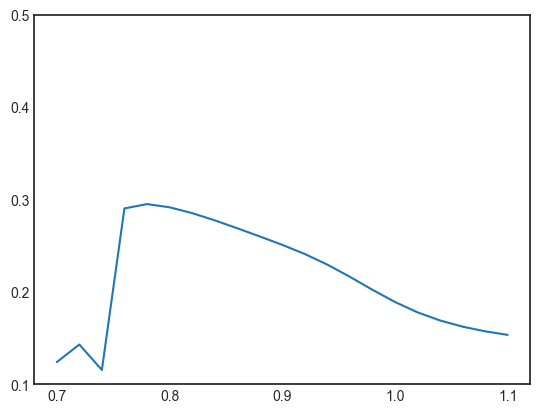

In [57]:
#plot the implied volatilitess of a vix option

plt.plot(ks, imp_vols);
plt.xticks(np.array([0.7, 0.8, 0.9, 1., 1.1]));
plt.yticks(np.array([0.1, 0.2, 0.3, 0.4, 0.5]));

# A Class for the VIX  and index model

In [58]:
class VixModel():
    """
    A class for a model for simulatnous pricing of S&P and VIX derivatives
    
    Arguments-
        tenor_dates - array of tenor dates (in years) starting with 0, 
                        defaulted to six month range np.arange(0, 1/2, 1/12)
        
        model_type - a string; the type of the model used for the jumps, either 'Merton' or 'Kou'
    """
    def __init__(self, tenor_dates = np.array([0, 1, 2, 3, 4, 7, 10])/12, model_type = 'Merton'):
        self.model_type = model_type
        self.tenor_dates = tenor_dates
        
        #the initial variance swap rates  V^0_0, ..., V^0_m-1
        #initialized to the values from the paper
        self.Vi_0 = np.array([0.041, 0.052, 0.056, 0.059, 0.062, 0.061])
        
        #Monte Carlo Data for tenors used to price Index Options
        self._stored_data = []
        
        #model parameters
        self.params = vix_model_parameters(model_type)

        if model_type == 'Merton':#Gaussian jumps model
            
            self.b_i = np.array([-0.140, -0.161, -0.162, -0.187, -0.198, -0.199])
                
            self.constraint_cf = self.params.lmbd*(self.params.m**2+self.params.delta**2)
            
        elif model_type == 'Kou':#Double exponential jumps
            
            self.b_i = np.array([-0.141, -0.159, -0.158, -0.187, -0.195 , -0.192])
            
            self.constraint_cf = 2*self.params.lmbd*(self.params.p/(self.params.alpha_plus**2)+\
                                    (1-self.params.p)/(self.params.alpha_minus**2))
            
        else:#other model
            raise ValueError("Uknown model")
        
    
    def store_tenor_data(self, num_paths=10**5):
    #simulate and store jumps and the diffusion terms per each tenor period


        #diffusions
        diff_V, diff_Z = simul_tenor_difussions(num_paths, self.tenor_dates, k1=self.params.k1)

        #jumps
        jumps_S, jumps_V = simul_tenor_jumps(self.params, num_paths, self.tenor_dates)

        #store the corresponding V^i_T_i values for i =0, ..., m-1
        VTi = get_vix_prices(self.Vi_0, diff_V[:,:-1], jumps_V[:,:-1], self.tenor_dates,\
                             self.params)
        
        
        self._stored_data = [diff_V, diff_Z, jumps_S, jumps_V, VTi]
        
# stored_data
        
    
    def get_index_prices(self):
        pass

    def vix_option_pricer(self, S0, K, T, r, option_type =  'call', pricing_method ='Kar&Madan'):
        
        return price_vixoptions(S0, K, T, r, self.params, pricing_method, option_type)
    
    def index_option_pricer(self, S0, strikes, tenor_index, r = 0., option_type =  'call'):
        """
        S0 - spot price
        K -  the strike price
        m - the number of the expiry date in tenor dates
        r - the interest rate
        option_type - type of the option either 'call' or 'put'
        """
        if self._stored_data == []:
            self.store_tenor_data()
        
        
        return price_index_options(S0, self.Vi_0, strikes, r, self.tenor_dates[:tenor_index+1],\
                                    self._stored_data, self.b_i, self.params, option_type)

    
    def fit_data(self, data):
        pass


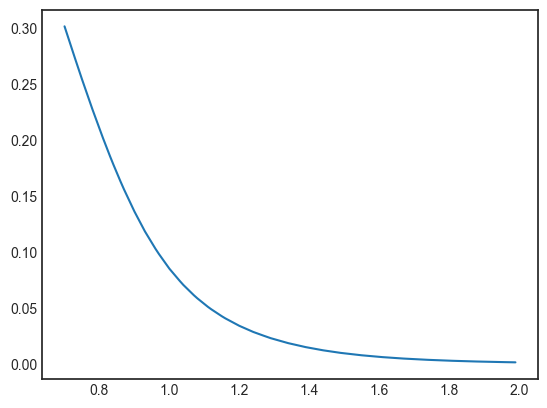

In [59]:
#creat an instance of VIX model class with Merton jumps
vx = VixModel( model_type = 'Merton')


# x, y = vx.simul_tenor_difussions(num_paths = 1)

#strikes
ks = np.arange(0.7, 2., 0.01)

#test the vix option pricer method
r = 0.0
T = 1/12
vix_option_vals = vx.vix_option_pricer(1, ks, T, r)


plt.plot(ks, vix_option_vals);


In [60]:
#store data
vx.store_tenor_data(num_paths= 5*10**6)

In [61]:
# #pick a tenor date index
# index = 1

# #set of strikes
# ks = np.arange(0.7, 1.1, 0.02)


# index_option_vals = vx.index_option_pricer(S0 = 1, strikes = ks, tenor_index = index)

In [62]:
# imp_vols = [implied_volatility(index_option_vals[i], 1, ks[i], tenor_dates[index], r) for i in range(len(ks))]

In [63]:
# plt.plot(ks, imp_vols);
# # plt.xticks(np.array([0.7, 0.8, 0.9, 1., 1.1]));
# plt.yticks(np.array([0.1, 0.2, 0.3, 0.4, 0.5]));

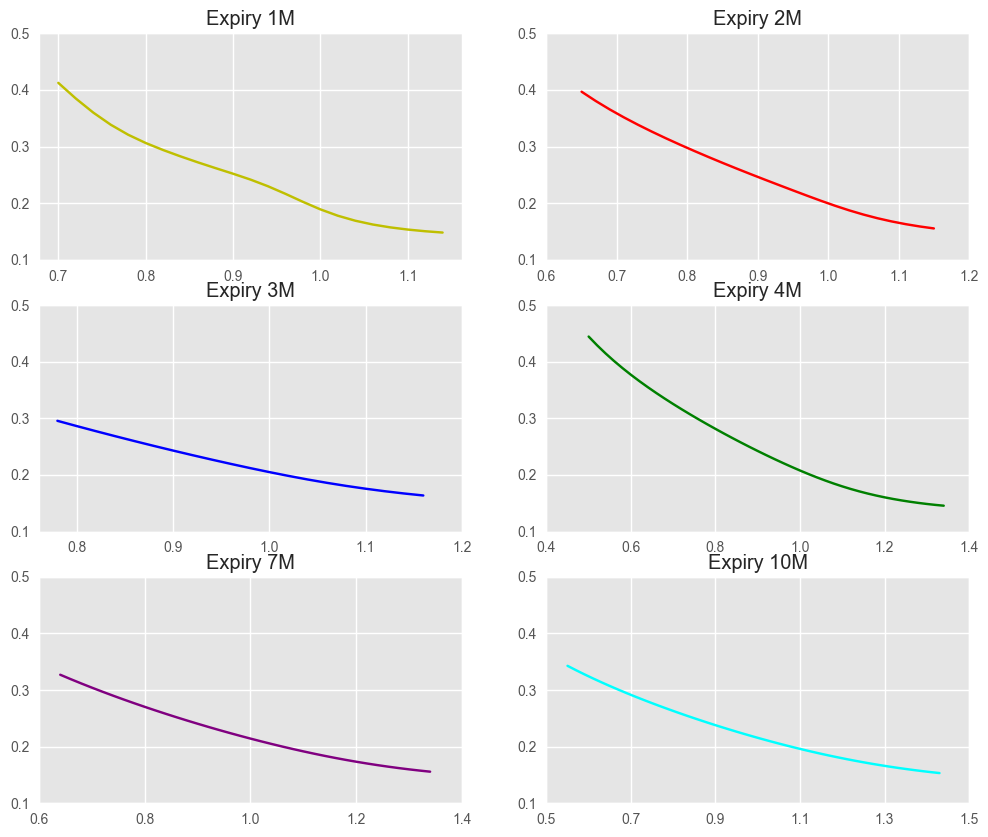

In [112]:
#reproducing the results in the paper for the index options
fig, axs = plt.subplots(3, 2, figsize=(12, 10))

xticks = [[0.7, 0.8, 0.9, 1., 1.1], [0.6, 0.7, 0.8, 0.9, 1., 1.1, 1.2],
          [0.8, 0.9, 1., 1.1, 1.2], [0.4, 0.6, 0.8, 1., 1.2, 1.4],\
          [0.6, 0.8, 1., 1.2, 1.4], [0.5, 0.7, 0.9, 1.1, 1.3, 1.5]]

strikes_list = [np.arange(0.7, 1.15, 0.02), np.arange(0.65, 1.17, 0.02),\
              np.arange(0.78, 1.18, 0.02), np.arange(0.5, 1.35, 0.02),\
              np.arange(0.64, 1.35, 0.02), np.arange(0.55, 1.44, 0.02)]

#plot the implied volatilites for each tenor date
colors = ['y', 'r', 'b', 'g', 'purple', 'cyan']
for j in range(6):
    
    ks = strikes_list[j]
    
    index_option_prices = vx.index_option_pricer(S0 = 1, strikes = ks, tenor_index = j+1)
    
    imp_vols = [implied_volatility(index_option_prices[i], 1, ks[i], tenor_dates[j+1], r) for i in range(len(ks))]
    
    ax = axs[j//2, j%2]
    ax.plot(ks, imp_vols, color = colors[j])
    ax.set_title(f"Expiry {int(12*tenor_dates[j+1])}M");
    ax.set_yticks(np.array([0.1, 0.2, 0.3, 0.4, 0.5]))
    ax.set_xticks(xticks[j])
    
plt.show()

In [65]:
import numpy as np
import matplotlib.pyplot as plt
# grid from 0 to 100

eps = 1e-10
min_x = 10+eps
max_x = 60-eps
x = np.linspace(min_x, max_x, 1000)

f = lambda x: (100-x)*np.log(x)


def plot_func_wguess(guess=23.947):
    val = f(guess)
    plt.plot(x, f(x))
    plt.plot(guess, f(guess), 'go')
    plt.legend(['f(x)', f'({guess}, {val:.7f})'])
    # horizontal dashed line at y=val
    plt.axhline(val, linestyle='--', color='k')
    plt.show()

# interactive plot with a slider for the guess
from ipywidgets import interact



In [66]:
interact(plot_func_wguess, guess=(min_x, max_x, 0.001))

interactive(children=(FloatSlider(value=23.947, description='guess', max=59.9999999999, min=10.0000000001, ste…

<function __main__.plot_func_wguess(guess=23.947)>

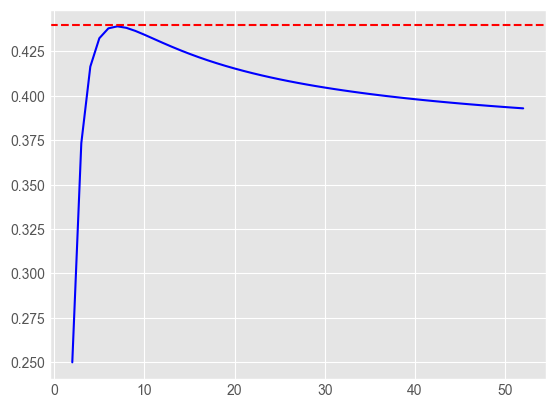

In [81]:
def g_func(n):
    x = 1/n
    return 1/(((n-1)**x)*(1-x)**n)

# def bx(x):
#     n = 1/x
#     return x*(1+x)**n

# (n-1)^(n+1/n)/n**n

ns = np.arange(2, 53, 1)
ys = g_func(ns)
zs = np.linspace(ys[0], ys[-1], len(ns))

plt.plot(ns, 1/ys, color='b')
plt.axhline(0.44, linestyle='--', color='r')
plt.show()

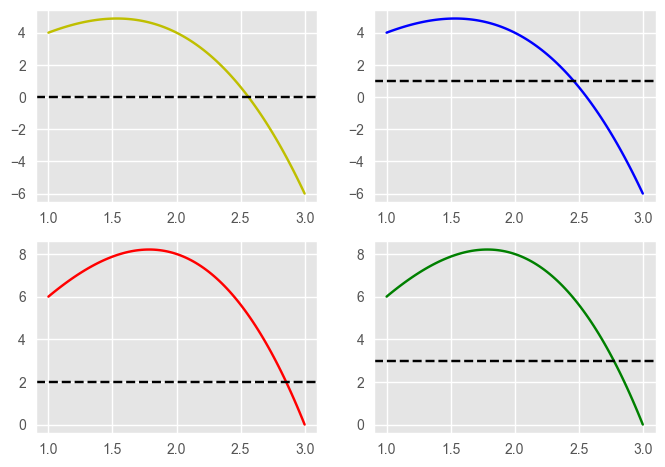

In [109]:
def mfunc(x, n, a = 1):
    return (a+x)**n - a**n - x**(n+1)
plt.style.use('ggplot')

xs = np.linspace(1, 3, 100)

fig, axs = plt.subplots(ncols=2, nrows=2)
axs = axs.flat

for i in range(4):
    col = ['y', 'b', 'r', 'g'][i]
    axs[i].plot(xs, mfunc(xs, 2, i//2+2), color=col) # to plot circles as circles
    # plot horizontal line at y=0
    axs[i].axhline(i, linestyle='--', color='k')
plt.show()